In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Building Pipelines

In [3]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([("scaler", MinMaxScaler()), ("svm", SVC())])

Here, we created two steps: the first, called "scaler", is an instance of MinMaxScaler, and the second, called "svm", is an instance of SVC. Now, we can fit the pipeline, like any other scikit-learn estimator.

In [4]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()), ('svm', SVC())])

 pipe.fit first calls fit on the first step (the scaler), then transforms the training data using the scaler, and finally fits the SVM with the scaled data. To evaluate on the test data, we simply call pipe.score.

In [5]:
print("Test score : {:.2f}".format(pipe.score(X_test, y_test)))

Test score : 0.98


Calling the score method on the pipeline first transforms the test data using the scaler, and then calls the score method on the SVM using the scaled test data.

# Using Pipelines in Grid Searches

Using a pipeline in a grid search works the same way as using any other estimator. We define a parameter grid to search over, and construct a GridSearchCV from the pipeline and the parameter grid.

When specifying the parameter grid, there is a slight change, though. We need to specify for each parameter which step of the pipeline it belongs to. Both parameters that we want to adjust, C and gamma, are parameters of SVC, the second step. We gave this step the name "svm".

The syntax to define a parameter grid for a pipeline is to specify for each parameter the step name, followed by __ (a double underscore), followed by the parameter name. To search over the C parameter of SVC we therefore have to use "svm__C" as the key in the parameter grid dictionary, and similarly for gamma.

In [6]:
param_grid = {'svm__C':[0.001, 0.01, 0.1, 1, 10, 100],
              'svm__gamma':[0.001, 0.01, 0.1, 1, 10, 100]}

With this parameter grid we can use GridSearchCV as usual.

In [7]:
from sklearn.model_selection import GridSearchCV


grid = GridSearchCV(pipe, param_grid=param_grid, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('svm', SVC())]),
             param_grid={'svm__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'svm__gamma': [0.001, 0.01, 0.1, 1, 10, 100]})

In [8]:
print("Best cross-validation accuracy: {:.2f}".format(grid.best_score_))
print("Test set score: {:.2f}".format(grid.score(X_test, y_test)))
print("Best parameters: {}".format(grid.best_params_))

Best cross-validation accuracy: 0.97
Test set score: 0.99
Best parameters: {'svm__C': 10, 'svm__gamma': 0.1}


In contrast to the grid search we did before, now for each split in the cross-validation, the MinMaxScaler is refit with only the training splits and no information is leaked from the test split into the parameter search.

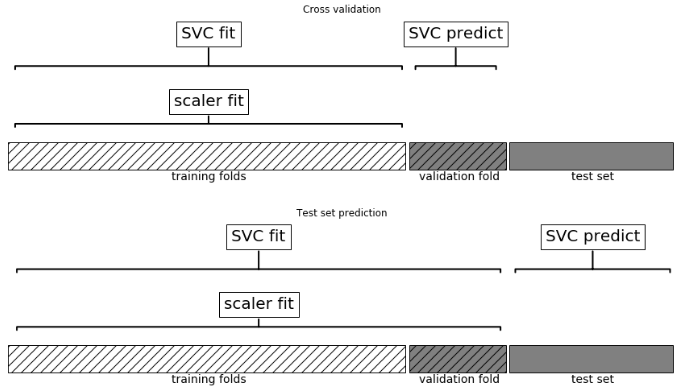

Scaling leakage slightly biases evaluation, but feature extraction or selection leakage can completely invalidate cross-validation results.

# The General Pipeline Interface

The Pipeline class is not restricted to preprocessing and classification, but can in fact join any number of estimators together. For example, you could build a pipeline containing feature extraction, feature selection, scaling, and classification, for a total of four steps. Similarly, the last step could be regression or clustering instead of classification.

The only requirement for estimators in a pipeline is that all but the last step need to have a transform method, so they can produce a new representation of the data that can be used in the next step.

Internally, during the call to Pipeline.fit, the pipeline calls fit and then transform on each step in turn, with the input given by the output of the transform method of the previous step. For the last step in the pipeline, just fit is called.

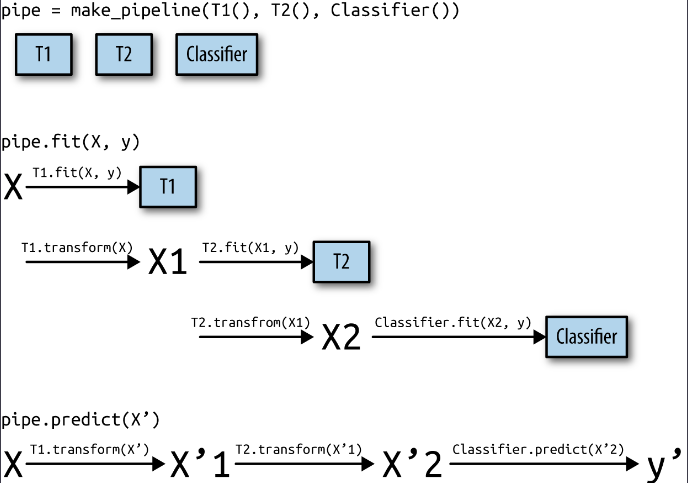

The pipeline is actually even more general than this. There is no requirement for the last step in a pipeline to have a predict function, and we could create a pipeline just containing, for example, a scaler and PCA. Then, because the last step (PCA) has a transform method, we could call transform on the pipeline to get the output of PCA.transform applied to the data that was processed by the previous step. The last step of a pipeline is only required to have a fit method.

# Convenient Pipeline Creation with make_pipeline

Creating a pipeline using the syntax described earlier is sometimes a bit cumbersome, and we often don’t need user-specified names for each step. There is a convenience function, make_pipeline, that will create a pipeline for us and automatically name each step based on its class.

In [9]:
from sklearn.pipeline import make_pipeline

# standard syntax
pipe_long = Pipeline([("scaler", MinMaxScaler()), ("svm", SVC(C=100))])

# abbreviated syntax
pipe_short = make_pipeline(MinMaxScaler(), SVC(C=100))

The pipeline objects pipe_long and pipe_short do exactly the same thing, but pipe_short has steps that were automatically named. We can see the names of the steps by looking at the steps attribute.

In [10]:
print("Pipeline steps: \n{}".format(pipe_short.named_steps))

Pipeline steps: 
{'minmaxscaler': MinMaxScaler(), 'svc': SVC(C=100)}


The steps are named minmaxscaler and svc. In general, the step names are just lowercase versions of the class names. If multiple steps have the same class, a number is appended

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipe = make_pipeline(StandardScaler(), PCA(n_components=2), StandardScaler())
print("Pipeline steps:\n{}".format(pipe.steps))

Pipeline steps:
[('standardscaler-1', StandardScaler()), ('pca', PCA(n_components=2)), ('standardscaler-2', StandardScaler())]


 The first StandardScaler step was named standardscaler-1 and the second standardscaler-2. However, in such settings it might be better to use the Pipeline construction with explicit names, to give more semantic names to each step.

# Accessing Step Attributes

Often you will want to inspect attributes of one of the steps of the pipeline—say, the coefficients of a linear model or the components extracted by PCA. The easiest way to access the steps in a pipeline is via the named_steps attribute, which is a dictionary from the step names to the estimators

In [12]:
pipe.fit(X)

# extract the first two principal components from the "pca" step
components = pipe.named_steps["pca"].components_
print("components.shape: {}".format(components.shape))

components.shape: (2, 30)


# Accessing Attributes in a Pipeline inside GridSearchCV

A common task is to access some of the steps of a pipeline inside a grid search. Let’s grid search a LogisticRegression classifier on the cancer dataset, using Pipeline and StandardScaler to scale the data before passing it to the LogisticRegression classifier. First we create a pipeline using the make_pipeline function.

In [13]:
from sklearn.linear_model import LogisticRegression

pipe = make_pipeline(StandardScaler(), LogisticRegression())

 the regularization parameter to tune for LogisticRegression is the parameter C. We use a logarithmic grid for this parameter, searching between 0.01 and 100. Because we used the make_pipeline function, the name of the LogisticRegression step in the pipeline is the lowercased class name, logisticregression. To tune the parameter C, we therefore have to specify a parameter grid for logisticregression__C.

In [14]:
param_grid = {'logisticregression__C':[0.01, 0.1, 1, 10, 100]}

In [15]:
grid = GridSearchCV(pipe, param_grid=param_grid, cv=5)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100]})

The best model found by GridSearchCV, trained on all the training data, is stored in grid.best_estimator_.



In [16]:
print("Best estimator:\n{}".format(grid.best_estimator_))

Best estimator:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(C=10))])


This best_estimator_ in our case is a pipeline with two steps, standardscaler and logisticregression. To access the logisticregression step, we can use the named_steps attribute of the pipeline.

In [17]:
print("Logistic Regression step: \n{}".format(grid.best_estimator_.named_steps["logisticregression"].coef_))

Logistic Regression step: 
[[-0.05352023 -0.20697861  0.174634   -0.30488669 -0.38264193  2.95369466
  -1.3478468  -3.40244083  0.90542286 -1.02094084 -3.62770834  0.67153524
  -0.12928174 -2.28852817 -0.3052475   0.06561542  0.34434964 -1.37361895
   1.35554268  2.08891994 -1.64776766 -2.42247589  0.10996999 -1.80883896
  -0.11667213  0.74638658 -2.37089034 -0.73466759 -2.68276382 -0.42592149]]


# Grid-Searching Preprocessing Steps and Model Parameters

Using pipelines, we can encapsulate all the processing steps in our machine learning workflow in a single scikit-learn estimator. Another benefit of doing this is that we can now adjust the parameters of the preprocessing using the outcome of a supervised task like regression or classification.

In [18]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()

X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt


pipe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(),
    Ridge())

Ideally we want to select the degree parameter based on the outcome of the classification. Using our pipeline, we can search over the degree parameter together with the parameter alpha of Ridge. To do this, we define a param_grid that contains both, appropriately prefixed by the step names.

In [20]:
param_grid = {'polynomialfeatures__degree': [1, 2, 3],
              'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

In [21]:
grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'polynomialfeatures__degree': [1, 2, 3],
                         'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

We can visualize the outcome of the cross-validation using a heat map.

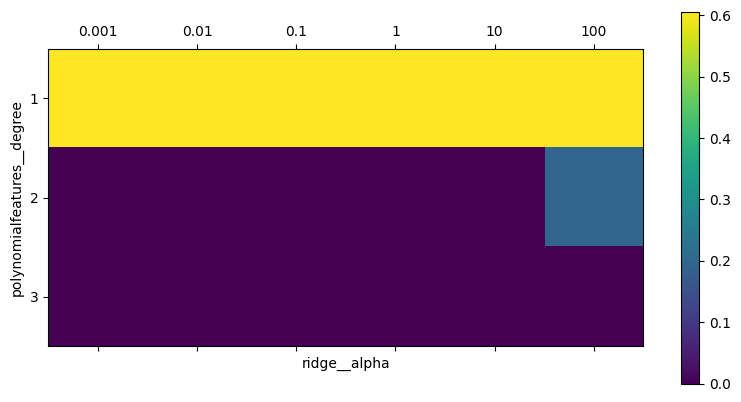

In [22]:
plt.matshow(grid.cv_results_['mean_test_score'].reshape(3, -1),
            vmin=0, cmap="viridis")
plt.xlabel("ridge__alpha")
plt.ylabel("polynomialfeatures__degree")
plt.xticks(range(len(param_grid['ridge__alpha'])), param_grid['ridge__alpha'])
plt.yticks(range(len(param_grid['polynomialfeatures__degree'])),
           param_grid['polynomialfeatures__degree'])

plt.colorbar()

In [23]:
print("Best parameters: {}".format(grid.best_params_))

Best parameters: {'polynomialfeatures__degree': 1, 'ridge__alpha': 10}


In [24]:
print("Test-set score: {:.2f}".format(grid.score(X_test, y_test)))

Test-set score: 0.59


Searching over preprocessing parameters together with model parameters is a very powerful strategy. However, keep in mind that GridSearchCV tries all possible combinations of the specified parameters. Therefore, adding more parameters to your grid exponentially increases the number of models that need to be built.

# Grid-Searching Which Model To Use

It is also possible to search over the actual steps being performed in the pipeline (say whether to use StandardScaler or MinMaxScaler). This leads to an even bigger search space and should be considered carefully. Trying all possible solutions is usually not a viable machine learning strategy.

Below an example comparing a RandomForestClassifier and an SVC on the iris dataset. We know that the SVC might need the data to be scaled, so we also search over whether to use StandardScaler or no preprocessing.

For the RandomForestClassifier, we know that no preprocessing is necessary.


We start by defining the pipeline. Here, we explicitly name the steps. We want two steps, one for the preprocessing and then a classifier. We can instantiate this using SVC and StandardScaler.

In [25]:
pipe = Pipeline([('preprocessing', StandardScaler()), ('classifier', SVC())])

Now we can define the parameter_grid to search over. We want the classifier to be either RandomForestClassifier or SVC. Because they have different parameters to tune, and need different preprocessing, we can make use of the list of search grids.



To assign an estimator to a step, we use the name of the step as the parameter name. When we wanted to skip a step in the pipeline (for example, because we don’t need preprocessing for the RandomForest), we can set that step to None.

In [26]:
from sklearn.ensemble import RandomForestClassifier

param_grid = [{'classifier':[SVC()],
               'preprocessing':[StandardScaler(), None],
               'classifier__gamma':[0.001, 0.01, 0.1, 1, 10, 100],
               'classifier__C':[0.001, 0.01, 0.1, 1, 10, 100]
               },
               {
                'classifier':[RandomForestClassifier(n_estimators=100)],
                'preprocessing': [None],
                'classifier__max_features':[1, 2, 3]}]

Now we can instantiate and run the grid search as usual, here on the cancer dataset.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing', StandardScaler()),
                                       ('classifier', SVC())]),
             param_grid=[{'classifier': [SVC()],
                          'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'classifier__gamma': [0.001, 0.01, 0.1, 1, 10, 100],
                          'preprocessing': [StandardScaler(), None]},
                         {'classifier': [RandomForestClassifier()],
                          'classifier__max_features': [1, 2, 3],
                          'preprocessing': [None]}])

In [28]:
print("Best params:\n{}\n".format(grid.best_params_))
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Test-set score: {:.2f}".format(grid.score(X_test, y_test)))

Best params:
{'classifier': SVC(), 'classifier__C': 10, 'classifier__gamma': 0.01, 'preprocessing': StandardScaler()}

Best cross-validation score: 0.99
Test-set score: 0.98


The outcome of the grid search is that SVC with StandardScaler preprocessing, C=10, and gamma=0.01 gave the best result.

# Avoiding Redundant Computation

When performing a large grid-search like the ones described earlier, the same steps are often used several times. For example, for each setting of the classifier, the StandardScaler is built again. For the StandardScaler this might not be a big issue, but if you are using a more expensive transformation (say, feature extraction with PCA or NMF), this is a lot of wasted computation. The easiest solution to this problem is caching computations. This can be done with the memory parameter of Pipeline, which takes a joblib.Memory object—or just a path to store the cache.

In [29]:
pipe = Pipeline([('preprocessing', StandardScaler()),
                 ('classifier', SVC())],
                 memory="cache_folder")

There are two downsides to this method. The cache is managed by writing to disk, which requires serialization and actually reading and writing from disk. This means that using memory will only accelerate relatively slow transformations. Just scaling the data is likely to be faster than trying to read the already scaled data from disk. For expensive transformations, this can still be a big win, though.

The other disadvantage is that using n_jobs can interfere with the caching. Depending on the execution order of the grid search, in the worst case a computation could be performed redundantly at the same time by n_jobs amount of workers before it is cached.

Both of these can be avoided by using a replacement for GridSearchCV provided by the **dask-ml library**. dask-ml allows you to avoid redundant computation while performing parallel computations, even distributed over a cluster. If you are using expensive pipelines and performing extensive parameter searches, you should definitely have a look at dask-ml.